In [25]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')

def window_vs(dir_path, col):
    df_all = []
    i = 0
    
    for folder in glob.glob(str(dir_path / "*" / "*")):   
        if os.path.isdir(folder):
            csv_path = Path(folder) / "beads_flow_interaction.csv"
            
            # CSVファイルが存在しないフォルダはスキップ
            if not csv_path.exists():
                continue
                
            df = pd.read_csv(csv_path)
            
            # データを格納するためのリストを持つ辞書を作成
            if col=='cos_var':
                df_empty = {'exp': [], 'radius': [], f'{col}': []}
            
                for r, d in df.groupby('radius'):
                    product = (d['cos_std']**2).mean()
                    
                    # 値を上書き（=）するのではなく、リストに末尾追加（append）します
                    df_empty[f'{col}'].append(product)
                    df_empty['radius'].append(r)
                    df_empty['exp'].append(i)
            
            else:
                df_empty = {'exp': [], 'radius': [], f'{col}': []}
                
                for r, d in df.groupby('radius'):
                    product = d[col].mean()
                    
                    # 値を上書き（=）するのではなく、リストに末尾追加（append）します
                    df_empty[f'{col}'].append(product)
                    df_empty['radius'].append(r)
                    df_empty['exp'].append(i)
                
            i += 1
            df_get = pd.DataFrame(df_empty)
            df_all.append(df_get)

    # 結合するデータがない場合の安全処理
    if len(df_all) == 0:
        return pd.DataFrame()
    
    df = pd.concat(df_all, ignore_index=True)

    radius=df['radius'].unique()
    
    mean = df.groupby('radius').mean()[f'{col}']
    sem = df.groupby('radius').std()[f'{col}']/np.sqrt(max(df['exp'])+1)
        
    return df, radius, mean, sem

[Text(0.5, 0, 'window size [μm]'),
 Text(0, 0.5, '$\\mathbf{v_c} \\cdot \\mathbf{v_{MT}}$'),
 (0.0, 30.0)]

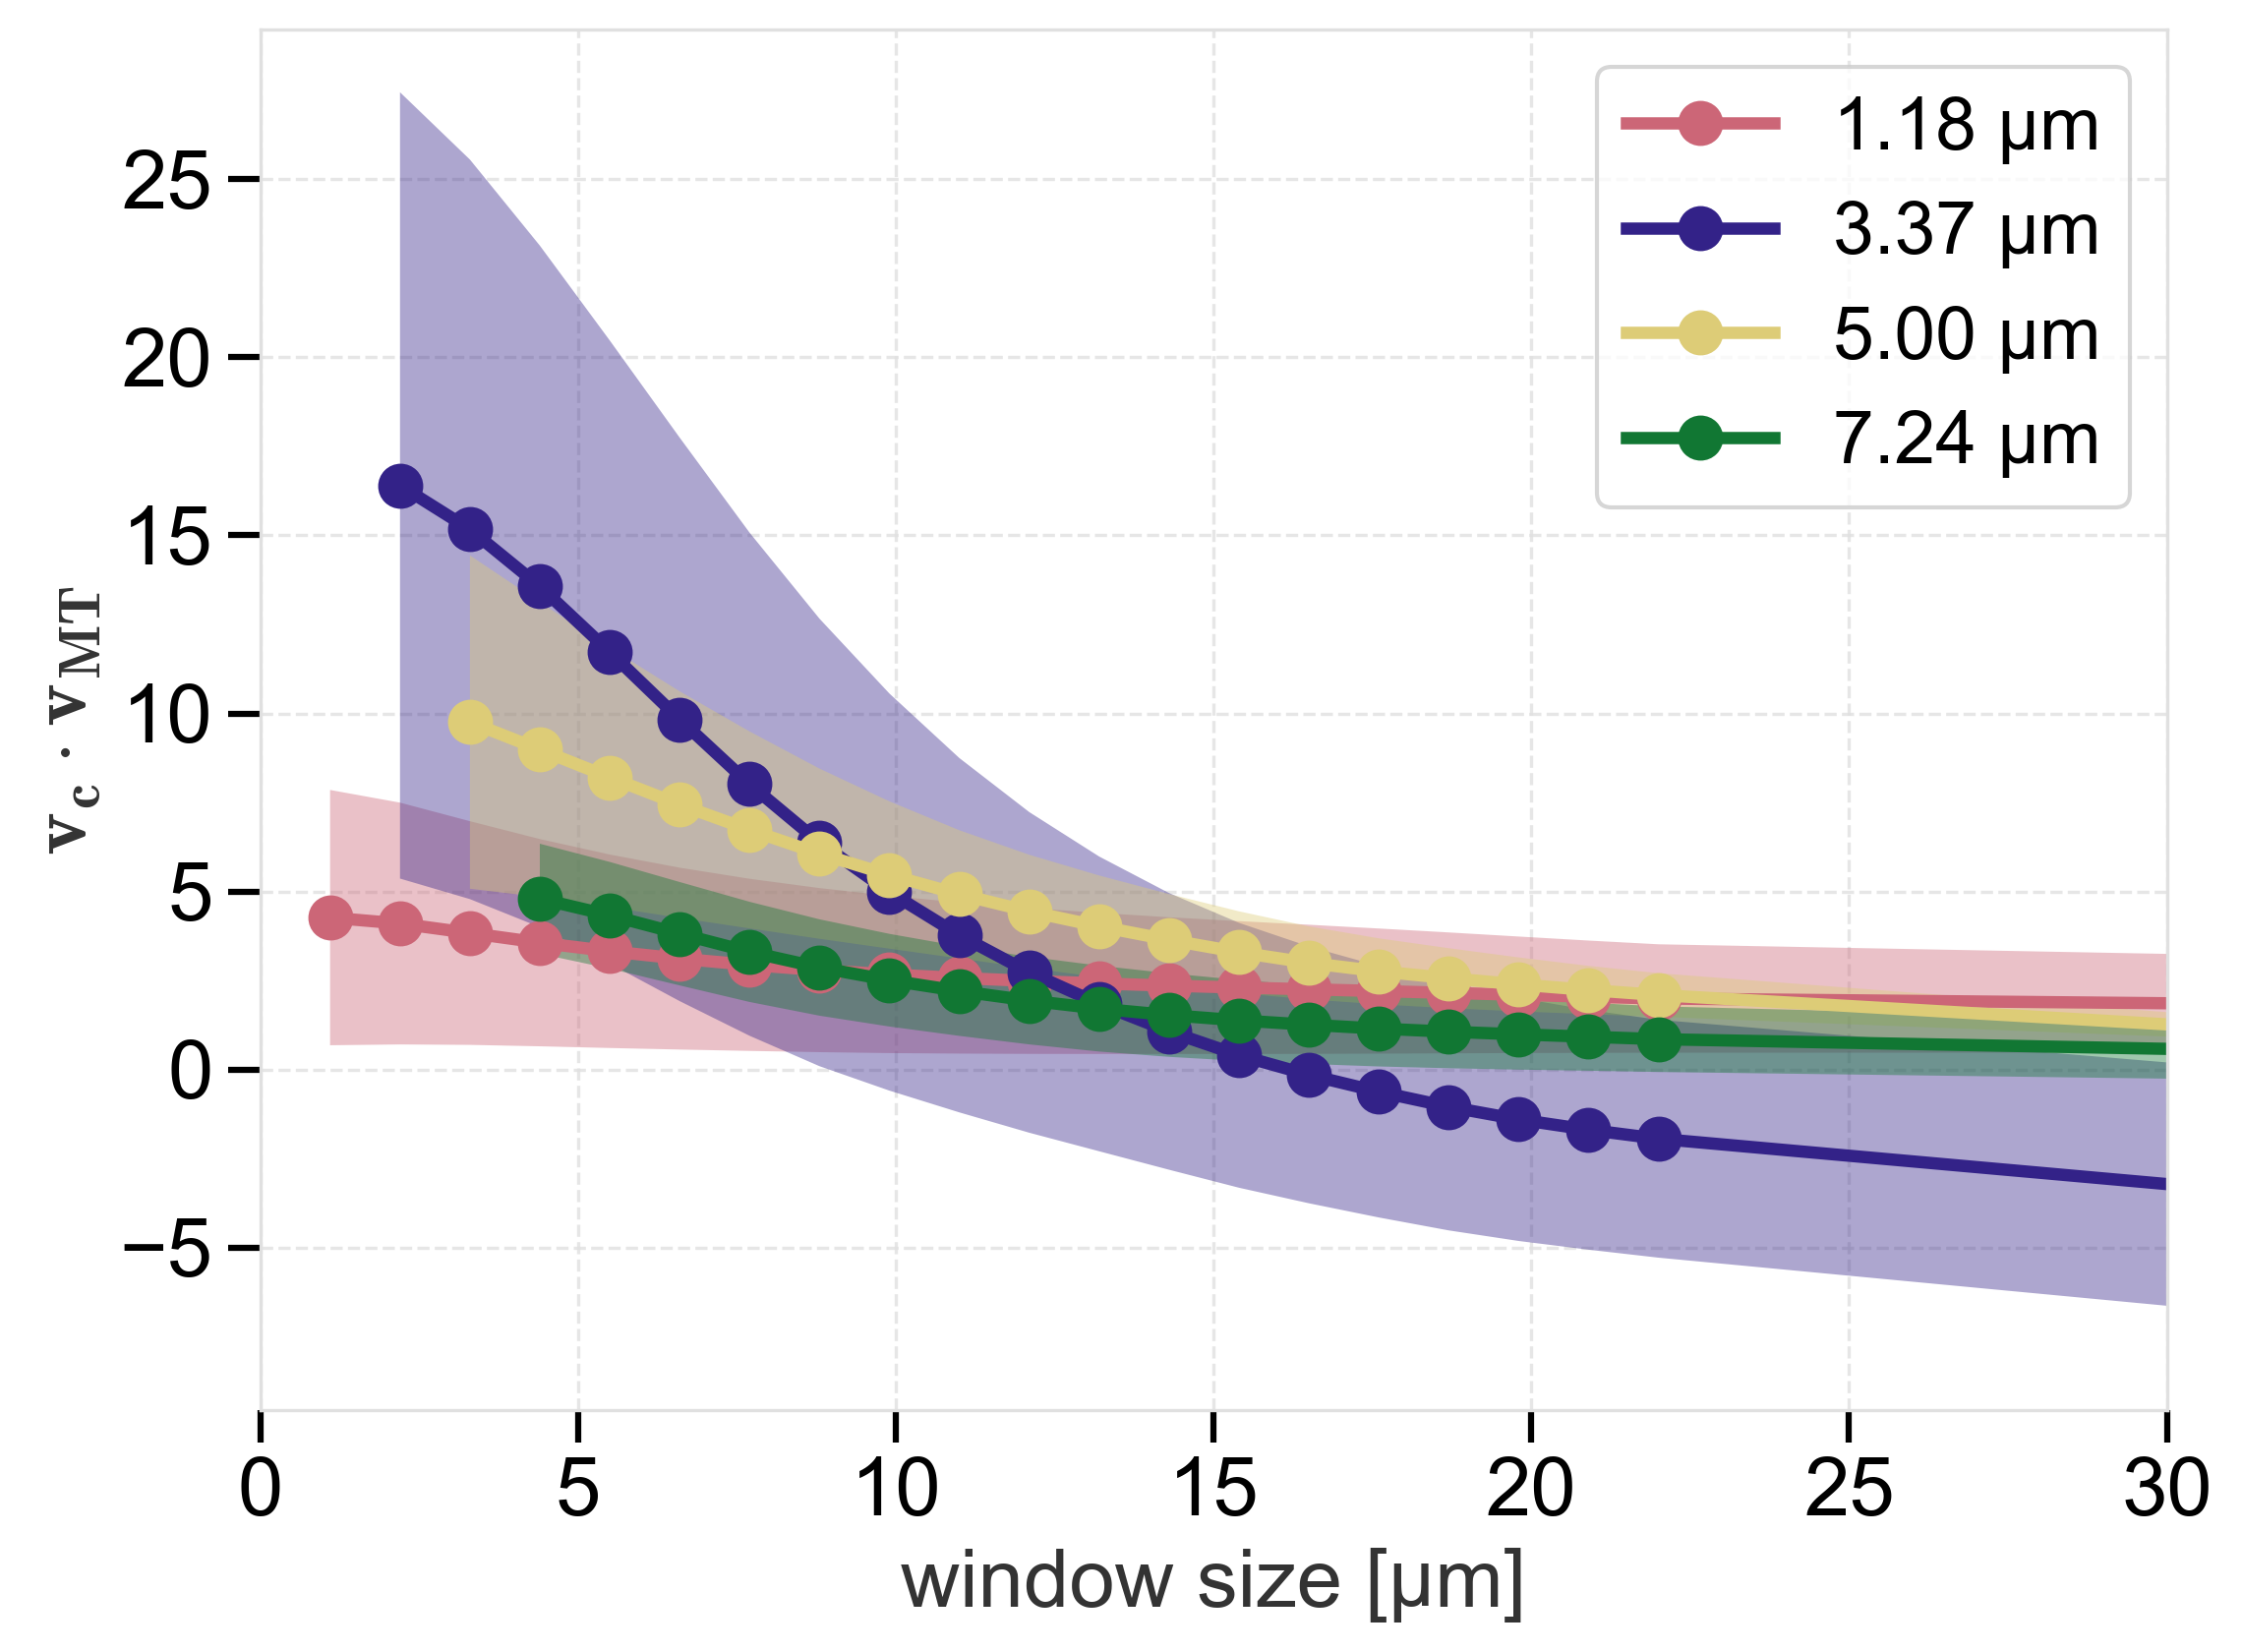

In [46]:
col = 'dot_product'

df_1, radius1, dot1, dot1sem = window_vs(root / "beads1um", col)
df_3, radius3, dot3, dot3sem = window_vs(root / "beads3um", col)
df_5, radius5, dot5, dot5sem = window_vs(root / "beads5um", col)
df_7, radius7, dot7, dot7sem = window_vs(root / "beads7um", col)

fig, ax = plt.subplots()
ax.plot(radius1*0.11, dot1, marker = 'o', label='1.18 \u03bcm')
ax.fill_between(radius1*0.11, dot1+dot1sem, dot1-dot1sem, alpha = 0.4)

ax.plot(radius3[1:]*0.11, dot3[1:], marker = 'o', label='3.37 \u03bcm')
ax.fill_between(radius3[1:]*0.11, dot3[1:]+dot3sem[1:], dot3[1:]-dot3sem[1:], alpha = 0.4)

ax.plot(radius5[2:]*0.11, dot5[2:], marker = 'o', label='5.00 \u03bcm')
ax.fill_between(radius5[2:]*0.11, dot5[2:]+dot5sem[2:], dot5[2:]-dot5sem[2:], alpha = 0.4)

ax.plot(radius7[3:]*0.11, dot7[3:], marker = 'o', label='7.24 \u03bcm')
ax.fill_between(radius7[3:]*0.11, dot7[3:]+dot7sem[3:], dot7[3:]-dot7sem[3:], alpha = 0.4)

ax.legend()

ax.set(xlabel='window size [\u03bcm]',
    ylabel= '$\\mathbf{v_c} \\cdot \\mathbf{v_{MT}}$',
    xlim = (0, 30))

[Text(0.5, 0, 'window size [μm]'),
 Text(0, 0.5, '$\\mathrm{cos}\\theta_\\mathrm{c,MT}$'),
 (0.0, 25.0)]

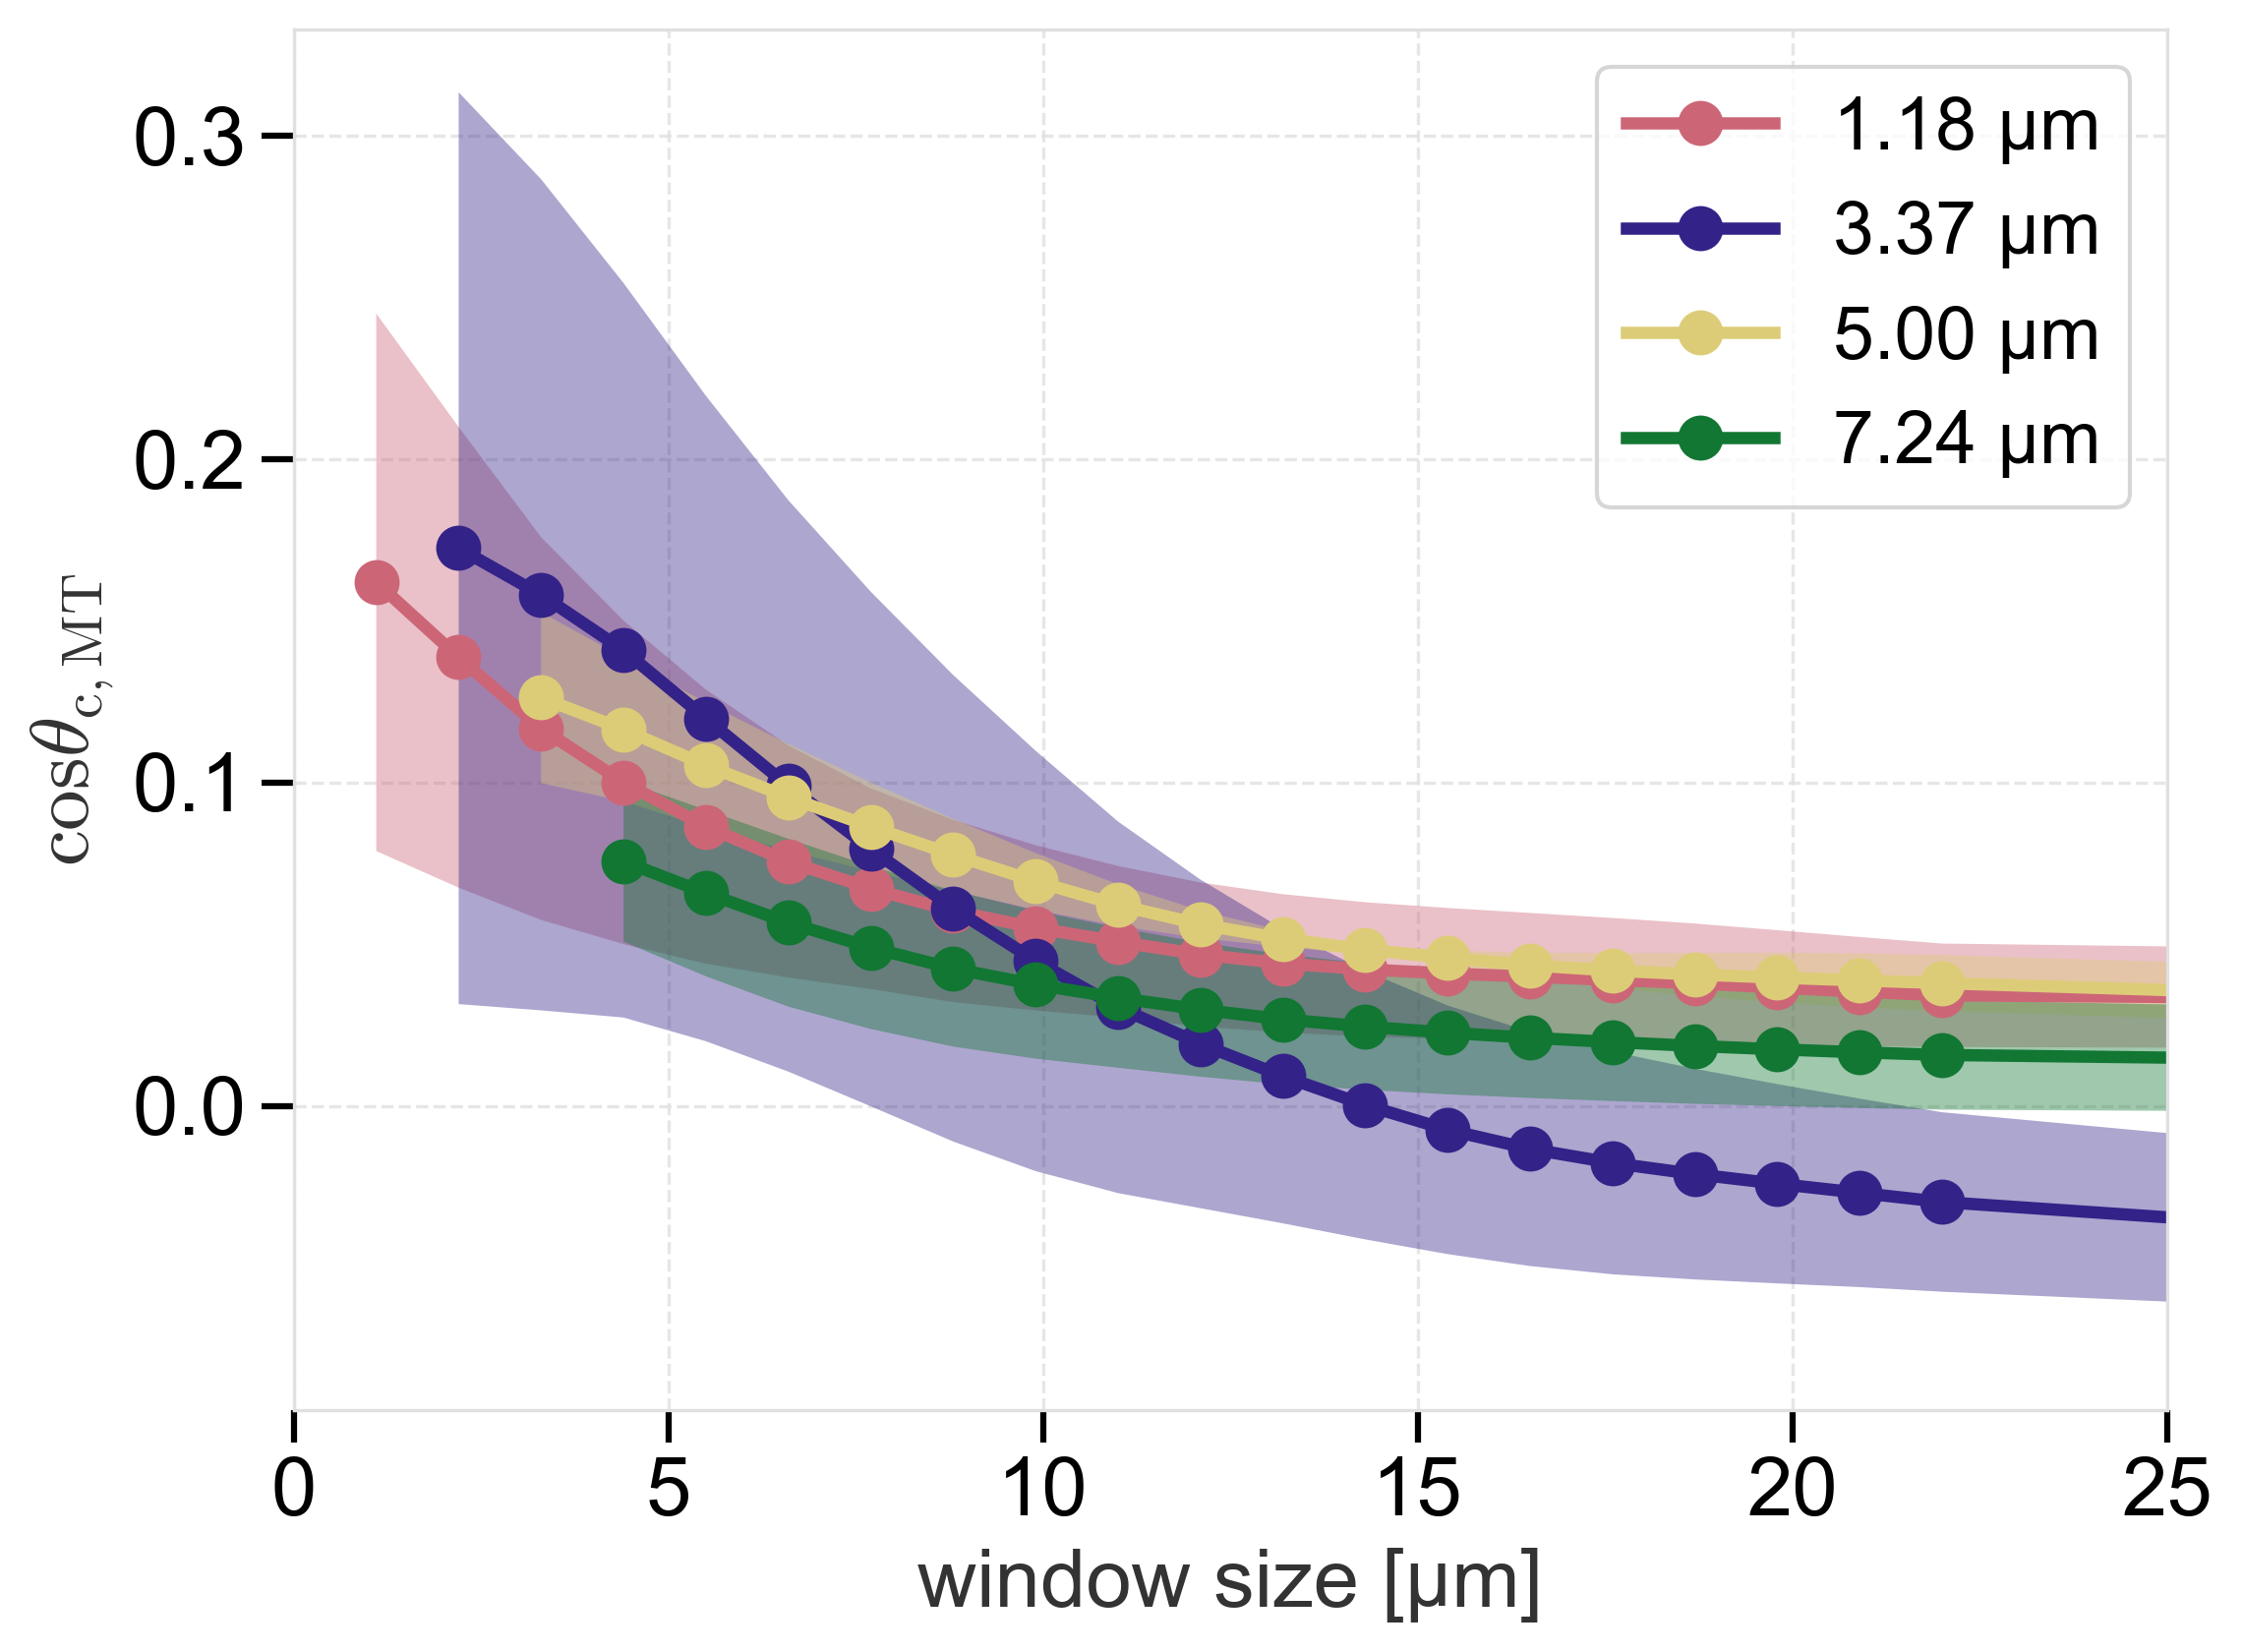

In [44]:
col = 'cos_sim'

df_1, radius1, dot1, dot1sem = window_vs(root / "beads1um", col)
df_3, radius3, dot3, dot3sem = window_vs(root / "beads3um", col)
df_5, radius5, dot5, dot5sem = window_vs(root / "beads5um", col)
df_7, radius7, dot7, dot7sem = window_vs(root / "beads7um", col)

fig, ax = plt.subplots()

ax.plot(radius1*0.11, dot1, marker = 'o', label='1.18 \u03bcm')
ax.fill_between(radius1*0.11, dot1+dot1sem, dot1-dot1sem, alpha = 0.4)

ax.plot(radius3[1:]*0.11, dot3[1:], marker = 'o', label='3.37 \u03bcm')
ax.fill_between(radius3[1:]*0.11, dot3[1:]+dot3sem[1:], dot3[1:]-dot3sem[1:], alpha = 0.4)

ax.plot(radius5[2:]*0.11, dot5[2:], marker = 'o', label='5.00 \u03bcm')
ax.fill_between(radius5[2:]*0.11, dot5[2:]+dot5sem[2:], dot5[2:]-dot5sem[2:], alpha = 0.4)

ax.plot(radius7[3:]*0.11, dot7[3:], marker = 'o', label='7.24 \u03bcm')
ax.fill_between(radius7[3:]*0.11, dot7[3:]+dot7sem[3:], dot7[3:]-dot7sem[3:], alpha = 0.4)

ax.legend()

ax.set(xlabel='window size [\u03bcm]',
    ylabel= '$\\mathrm{cos}\\theta_\\mathrm{c,MT}$',
    xlim = (0, 25))

[Text(0.5, 0, 'window size [μm]'),
 Text(0, 0.5, '$\\langle\\Delta\\mathrm{cos}^2\\theta_\\mathrm{c,MT}\\rangle$'),
 (0.0, 25.0)]

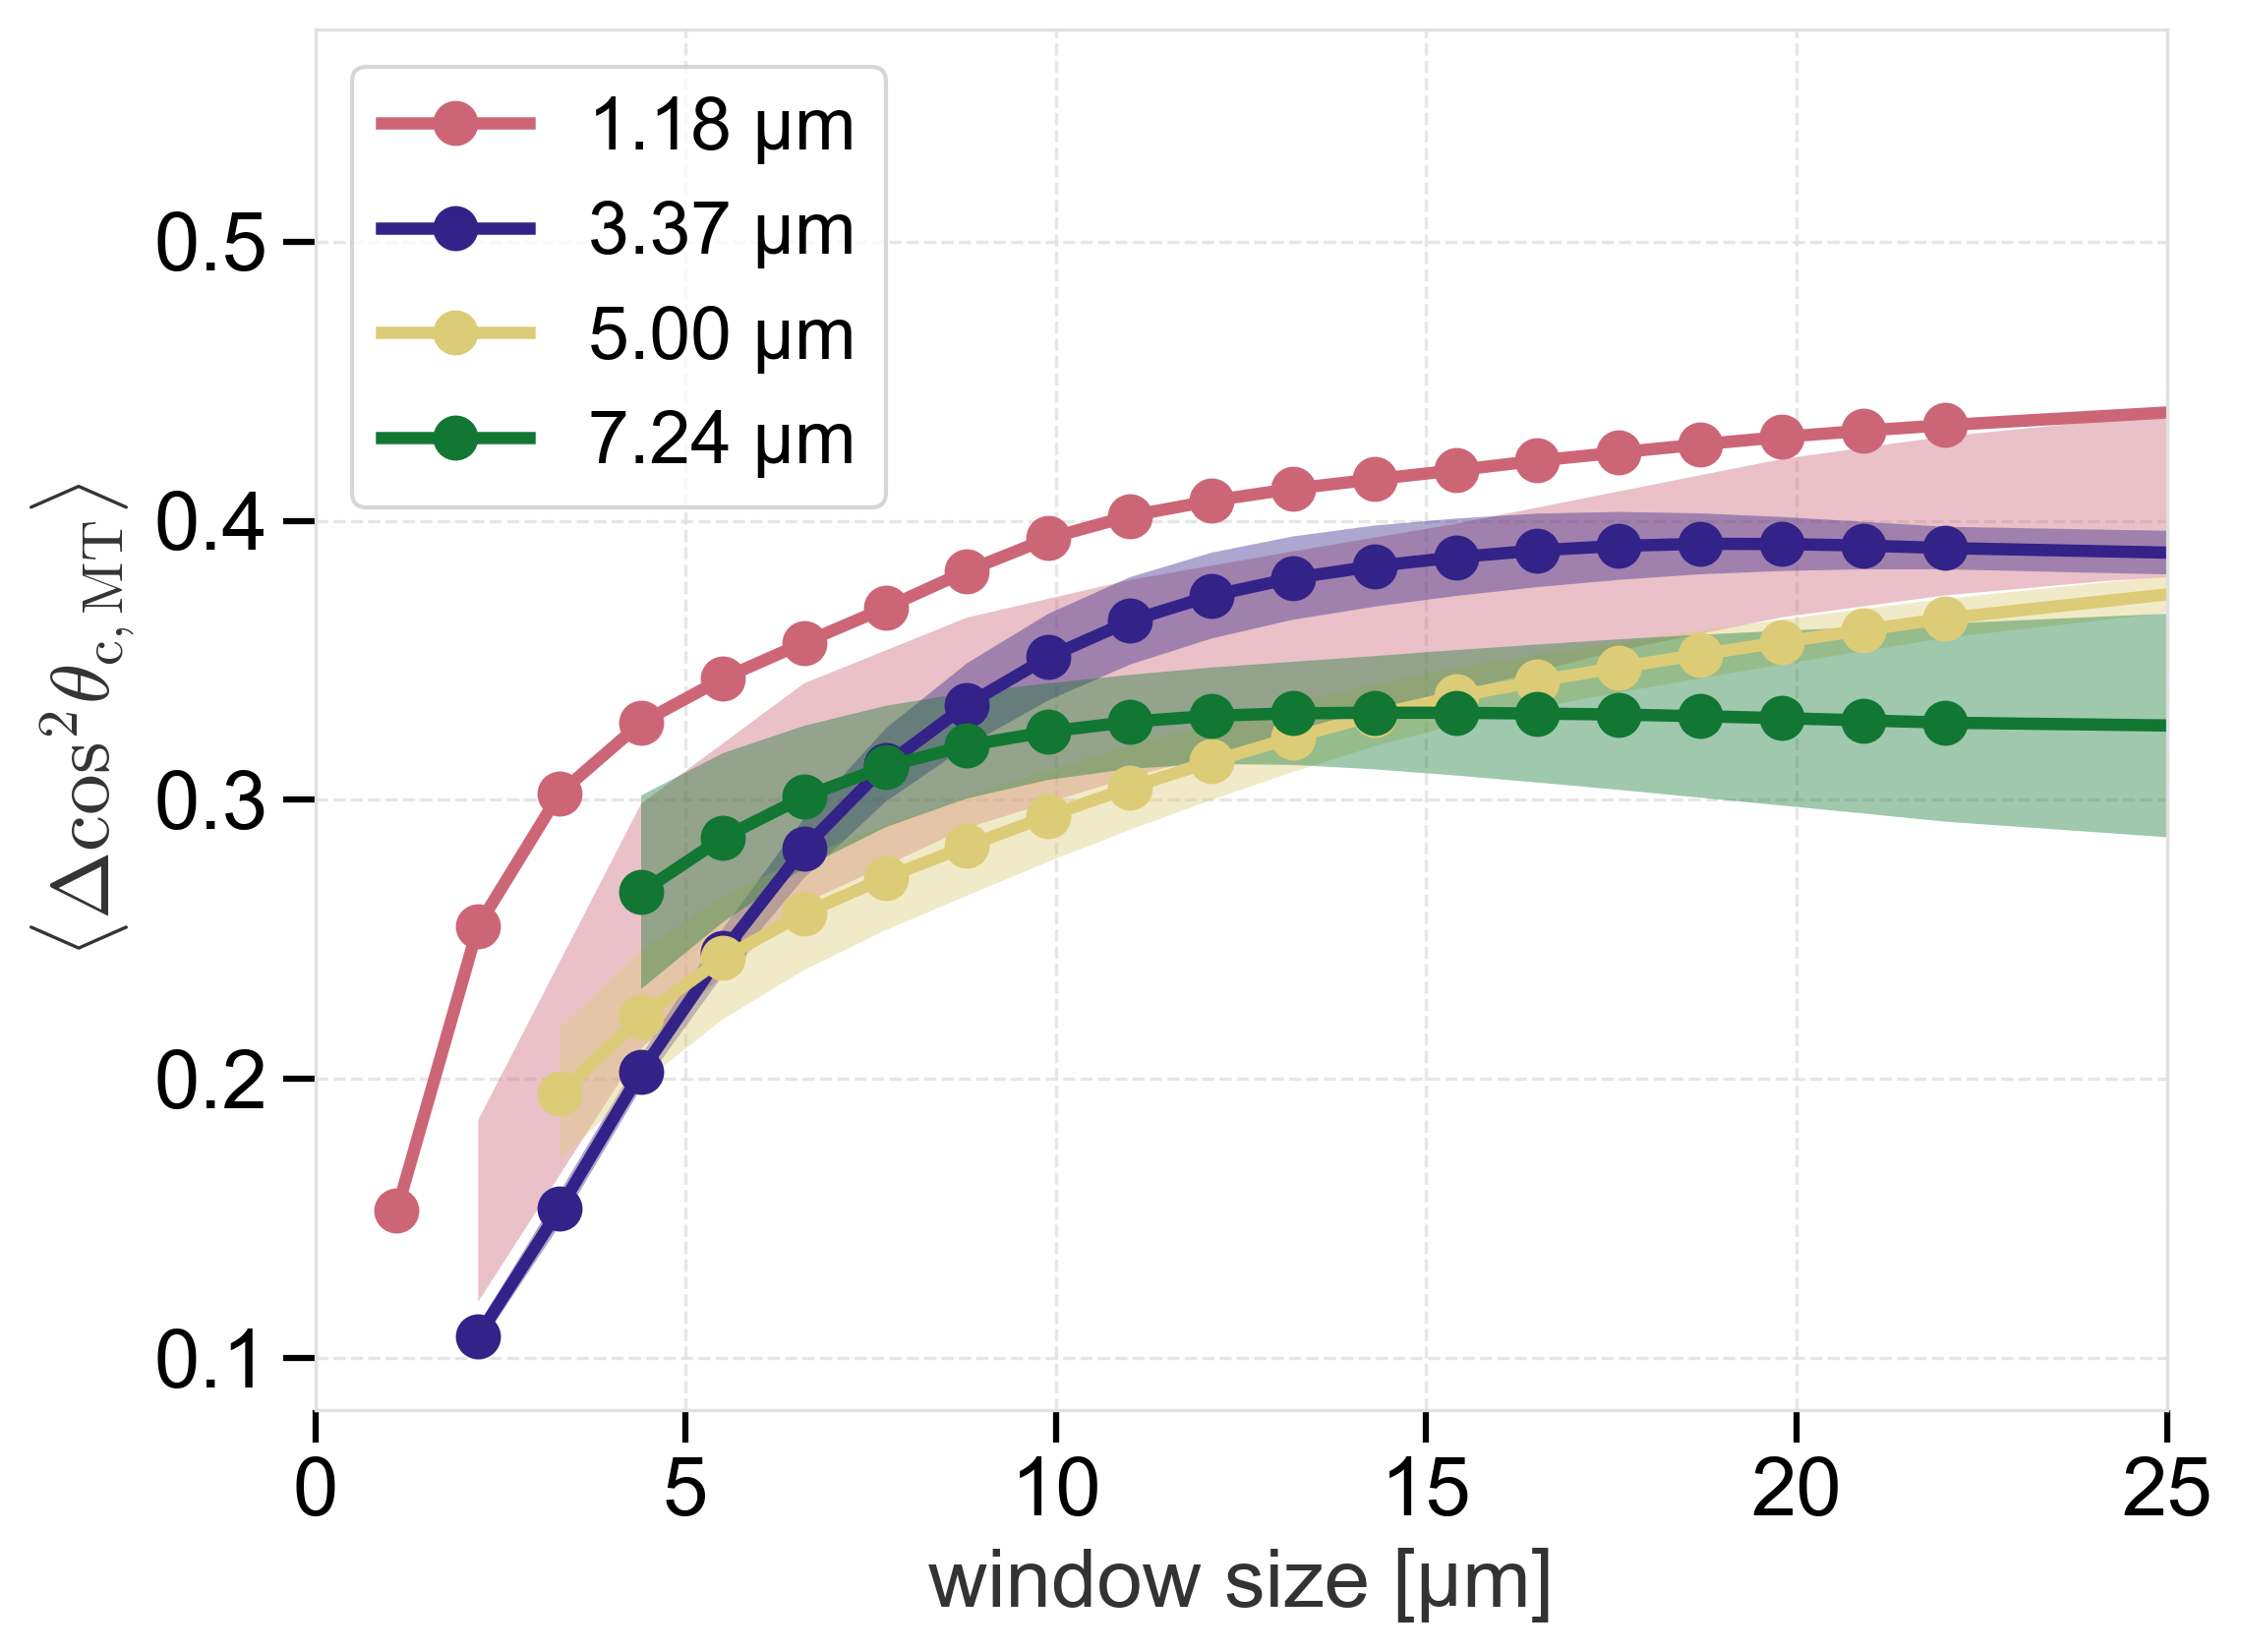

In [43]:
col = 'cos_var'

df_1, radius1, dot1, dot1sem = window_vs(root / "beads1um", col)
df_3, radius3, dot3, dot3sem = window_vs(root / "beads3um", col)
df_5, radius5, dot5, dot5sem = window_vs(root / "beads5um", col)
df_7, radius7, dot7, dot7sem = window_vs(root / "beads7um", col)

fig, ax = plt.subplots()

ax.plot(radius1*0.11, dot1, marker = 'o', label='1.18 \u03bcm')
ax.fill_between(radius1*0.11*2, dot1+dot1sem, dot1-dot1sem, alpha = 0.4)

ax.plot(radius3[1:]*0.11, dot3[1:], marker = 'o', label='3.37 \u03bcm')
ax.fill_between(radius3[1:]*0.11, dot3[1:]+dot3sem[1:], dot3[1:]-dot3sem[1:], alpha = 0.4)

ax.plot(radius5[2:]*0.11, dot5[2:], marker = 'o', label='5.00 \u03bcm')
ax.fill_between(radius5[2:]*0.11, dot5[2:]+dot5sem[2:], dot5[2:]-dot5sem[2:], alpha = 0.4)

ax.plot(radius7[3:]*0.11, dot7[3:], marker = 'o', label='7.24 \u03bcm')
ax.fill_between(radius7[3:]*0.11, dot7[3:]+dot7sem[3:], dot7[3:]-dot7sem[3:], alpha = 0.4)

ax.legend()

ax.set(xlabel='window size [\u03bcm]',
    ylabel= '$\\langle\\Delta\\mathrm{cos}^2\\theta_\mathrm{c,MT}\\rangle$',
    xlim = (0, 25))